In [1]:
# ============================================================
# NOTEBOOK 2 — CLUSTERING
# Player Segmentation in Professional Padel
# Business Objective: Segment players into strategic profiles
# to help sponsors, federations and analysts target the right players
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
# ============================================================
# 1. DATA LOADING
# ============================================================
ranking = pd.read_csv('../data/clean_dim_ranking.csv')
players = pd.read_csv('../data/clean_players.csv')

print(f"Ranking dataset shape: {ranking.shape}")
print(f"Players dataset shape: {players.shape}")
print(f"\nRanking columns: {list(ranking.columns)}")
print(f"Players columns: {list(players.columns)}")

Ranking dataset shape: (4111, 6)
Players dataset shape: (1054, 13)

Ranking columns: ['player_name', 'country', 'points', 'position', 'move', 'gender']
Players columns: ['id', 'name', 'category', 'gender', 'ranking', 'points', 'nationality', 'birthplace', 'birthdate', 'age', 'hand', 'side', 'height']


In [4]:
# ============================================================
# 2. DATA MERGING & EDA
# ============================================================
# Merge on player name
df = ranking.merge(
    players[['name', 'age', 'height', 'nationality', 'hand', 'side']],
    left_on='player_name',
    right_on='name',
    how='left'
)

print(f"Merged dataset shape: {df.shape}")
print(f"\nMissing values after merge:")
print(df.isnull().sum())
print(f"\nSample:")
df.head()

Merged dataset shape: (4114, 12)

Missing values after merge:
player_name       0
country           0
points            0
position          0
move              0
gender            0
name           3354
age            3384
height         3665
nationality    3354
hand           4010
side           3658
dtype: int64

Sample:


,player_name,country,points,position,move,gender,name,age,height,nationality,hand,side
0,Arturo Coello,ESP,19800,1,0,M,Arturo Coello,23.0,190.0,ES,left,drive
1,Agustin Tapia,ARG,19800,1,0,M,Agustin Tapia,26.0,179.0,AR,right,backhand
2,Alejandro Galan,ESP,17320,3,0,M,Alejandro Galan,29.0,186.0,ES,right,backhand
3,Federico Chingotto,ARG,17320,3,0,M,Federico Chingotto,28.0,170.0,AR,right,drive
4,Franco Stupaczuk,ARG,7905,5,0,M,Franco Stupaczuk,29.0,180.0,AR,right,backhand


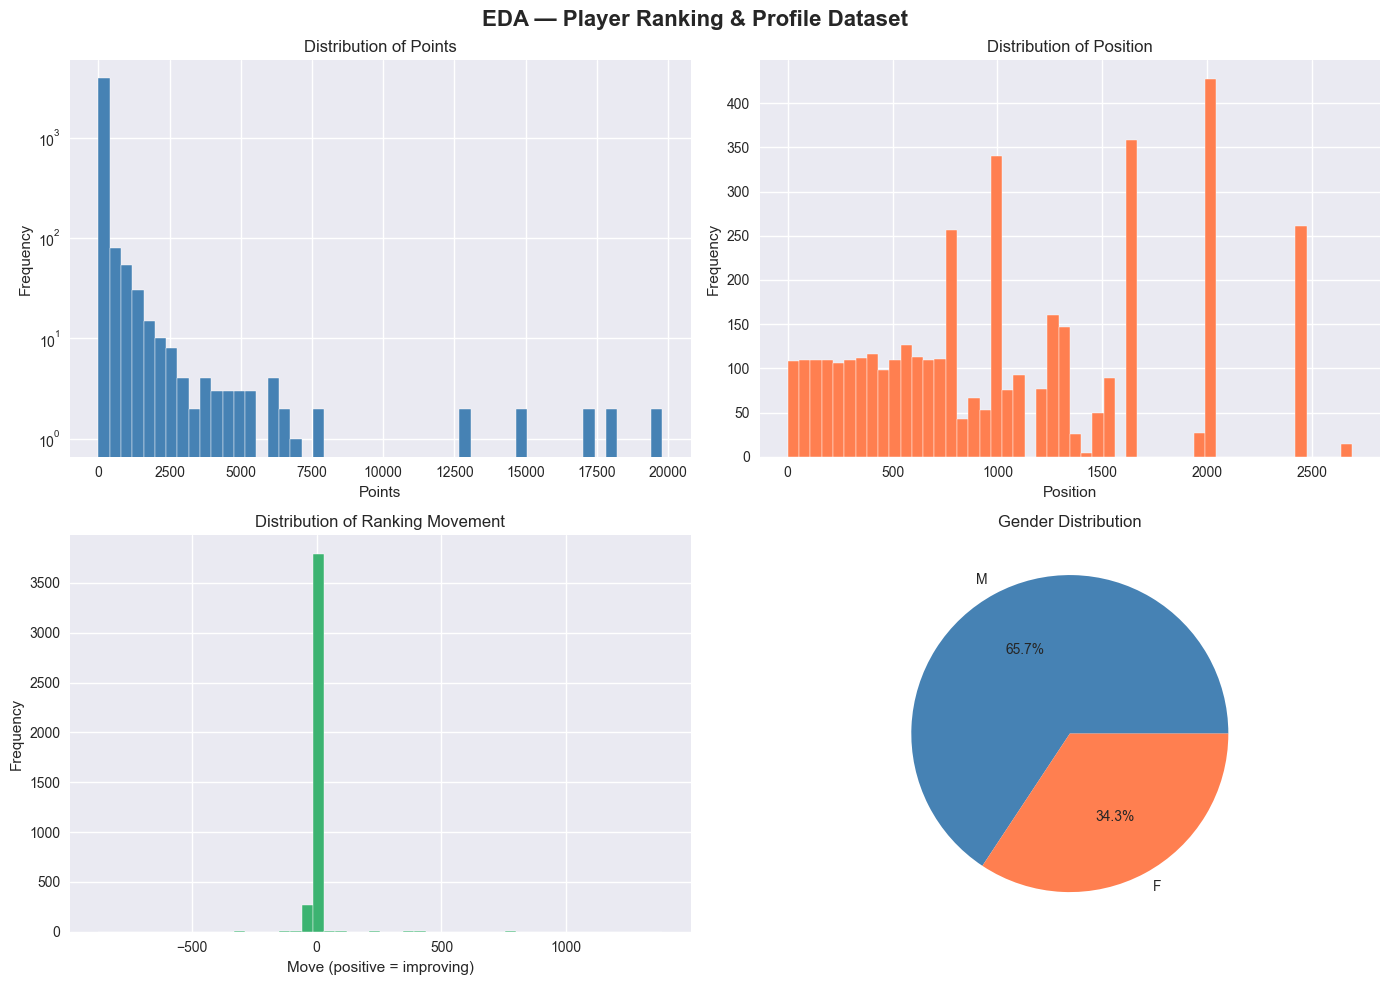

✅ EDA saved


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Player Ranking & Profile Dataset', fontsize=16, fontweight='bold')

# Points distribution
axes[0,0].hist(df['points'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of Points')
axes[0,0].set_xlabel('Points')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_yscale('log')

# Position distribution
axes[0,1].hist(df['position'], bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Distribution of Position')
axes[0,1].set_xlabel('Position')
axes[0,1].set_ylabel('Frequency')

# Move distribution
axes[1,0].hist(df['move'], bins=50, color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Distribution of Ranking Movement')
axes[1,0].set_xlabel('Move (positive = improving)')
axes[1,0].set_ylabel('Frequency')

# Gender distribution
gender_counts = df['gender'].value_counts()
axes[1,1].pie(gender_counts.values, labels=gender_counts.index,
              autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1,1].set_title('Gender Distribution')

plt.tight_layout()
plt.savefig('../outputs/eda_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA saved")

In [6]:
# ============================================================
# 3. FEATURE ENGINEERING & PREPROCESSING
# ============================================================

df_ml = df.copy()

# Fill missing values
df_ml['age'] = df_ml['age'].fillna(df_ml['age'].median())
df_ml['height'] = df_ml['height'].fillna(df_ml['height'].median())
df_ml['move'] = df_ml['move'].fillna(0)

# Encode gender
le = LabelEncoder()
df_ml['gender_encoded'] = le.fit_transform(df_ml['gender'])

# Feature engineering
df_ml['points_log'] = np.log1p(df_ml['points'])
df_ml['elite_score'] = (df_ml['points'] / df_ml['points'].max()) * 100
df_ml['momentum'] = df_ml['move'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))

# Select features for clustering
feature_cols = ['points_log', 'position', 'move', 'gender_encoded', 'elite_score']
X = df_ml[feature_cols].copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"✅ Features for clustering: {feature_cols}")
print(f"Shape: {X_scaled_df.shape}")
print(f"\nScaled features stats:")
print(X_scaled_df.describe().round(3))

✅ Features for clustering: ['points_log', 'position', 'move', 'gender_encoded', 'elite_score']
Shape: (4114, 5)

Scaled features stats:
       points_log  position      move  gender_encoded  elite_score
count    4114.000  4114.000  4114.000        4114.000     4114.000
mean        0.000     0.000     0.000          -0.000        0.000
std         1.000     1.000     1.000           1.000        1.000
min        -1.348    -1.560   -18.895          -1.384       -0.163
25%        -0.662    -0.818    -0.041          -1.384       -0.159
50%        -0.283    -0.076     0.024           0.723       -0.154
75%         0.440     0.817     0.067           0.723       -0.129
max         4.397     2.397    30.004           0.723       20.401


In [7]:
# ============================================================
# 4. MODEL EXPLANATION
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║              MODEL 1: K-MEANS CLUSTERING                     ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Partitions data into K clusters by minimizing the         ║
║   sum of squared distances from each point to its           ║
║   cluster centroid. Iteratively assigns points and          ║
║   updates centroids until convergence.                      ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - n_clusters (K): number of clusters to form             ║
║   - init: centroid initialization method (k-means++)       ║
║   - max_iter: maximum iterations for convergence           ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - Clusters are spherical and roughly equal size          ║
║   - Features are scaled (mean=0, std=1)                    ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Must specify K in advance                              ║
║   - Sensitive to outliers                                  ║
║   - Assumes convex cluster shapes                          ║
║                                                             ║
║ WHY CHOSEN:                                                 ║
║   - Simple and interpretable for business stakeholders     ║
║   - Works well with player ranking data                    ║
║   - Fast and scalable to 4000+ players                     ║
╚══════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════╗
║              MODEL 2: DBSCAN CLUSTERING                      ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Density-Based Spatial Clustering. Groups points that      ║
║   are closely packed together, marking points in low-       ║
║   density regions as outliers (noise = -1).                ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - eps: maximum distance between two points to be         ║
║           considered neighbors                             ║
║   - min_samples: minimum points to form a dense region     ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - Clusters can have arbitrary shapes                     ║
║   - Data has regions of high and low density               ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Sensitive to eps and min_samples parameters            ║
║   - Struggles with varying density clusters                ║
║                                                             ║
║ WHY CHOSEN:                                                 ║
║   - Automatically detects outlier players                  ║
║   - No need to specify number of clusters                  ║
║   - Identifies unusual player profiles naturally           ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              MODEL 1: K-MEANS CLUSTERING                     ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Partitions data into K clusters by minimizing the         ║
║   sum of squared distances from each point to its           ║
║   cluster centroid. Iteratively assigns points and          ║
║   updates centroids until convergence.                      ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - n_clusters (K): number of clusters to form             ║
║   - init: centroid initialization method (k-means++)       ║
║   - max_iter: maximum iterations for convergence           ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - Clusters are spherical and rough

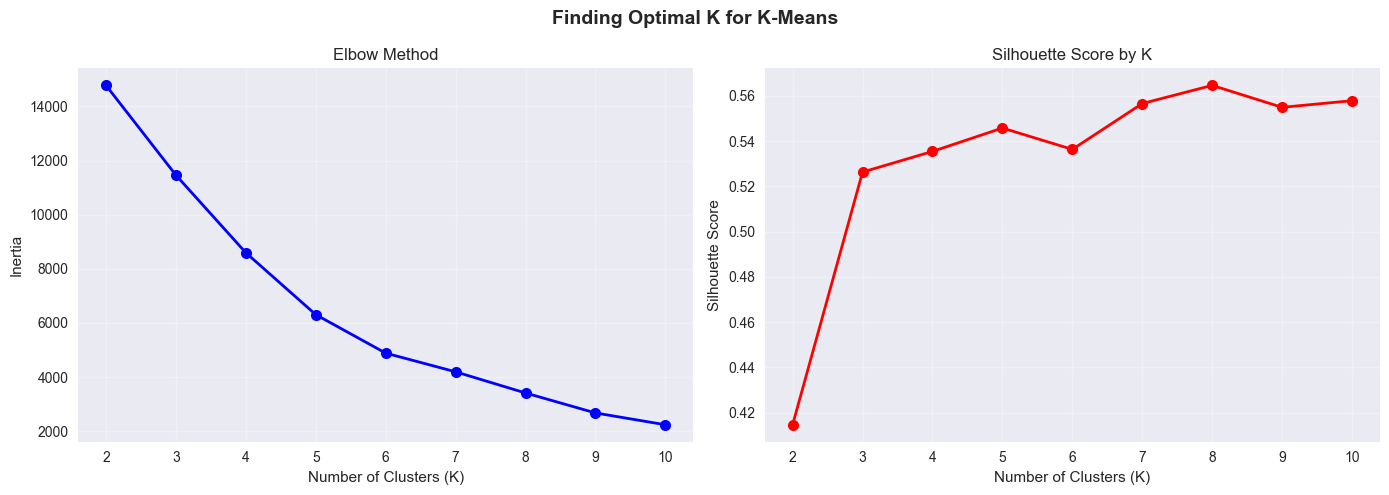

✅ Optimal K: 8
✅ Best Silhouette Score: 0.5647

All Silhouette Scores:
  K=2: 0.4146
  K=3: 0.5263
  K=4: 0.5355
  K=5: 0.5458
  K=6: 0.5364
  K=7: 0.5566
  K=8: 0.5647
  K=9: 0.5549
  K=10: 0.5579


In [9]:
# ============================================================
# 5. ELBOW METHOD — Finding optimal K
# ============================================================
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, algorithm='lloyd')
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finding Optimal K for K-Means', fontsize=14, fontweight='bold')

# Elbow curve
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"✅ Optimal K: {optimal_k}")
print(f"✅ Best Silhouette Score: {max(silhouette_scores):.4f}")
print(f"\nAll Silhouette Scores:")
for k, s in zip(k_range, silhouette_scores):
    print(f"  K={k}: {s:.4f}")

In [10]:
# ============================================================
# 6. MODEL 1 — K-MEANS CLUSTERING
# ============================================================
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df_ml['kmeans_cluster'] = kmeans_labels

# Evaluation
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"✅ K-Means Results (K={optimal_k}):")
print(f"   Silhouette Score: {kmeans_silhouette:.4f} (higher is better, max=1)")
print(f"   Davies-Bouldin Index: {kmeans_db:.4f} (lower is better)")
print(f"\nCluster sizes:")
print(df_ml['kmeans_cluster'].value_counts().sort_index())

✅ K-Means Results (K=8):
   Silhouette Score: 0.5647 (higher is better, max=1)
   Davies-Bouldin Index: 0.5881 (lower is better)

Cluster sizes:
kmeans_cluster
0    1557
1     445
2      10
3     903
4    1027
5      14
6     149
7       9
Name: count, dtype: int64


In [11]:
# ============================================================
# 7. MODEL 2 — DBSCAN CLUSTERING
# ============================================================
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
df_ml['dbscan_cluster'] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"✅ DBSCAN Results:")
print(f"   Number of clusters found: {n_clusters_dbscan}")
print(f"   Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f"\nCluster distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

# Silhouette for DBSCAN (excluding noise)
mask = dbscan_labels != -1
if mask.sum() > 1 and len(set(dbscan_labels[mask])) > 1:
    dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_db = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    print(f"\n   Silhouette Score (excl. noise): {dbscan_silhouette:.4f}")
    print(f"   Davies-Bouldin Index (excl. noise): {dbscan_db:.4f}")
else:
    dbscan_silhouette = 0
    dbscan_db = 999
    print("   Not enough clusters for silhouette score")

✅ DBSCAN Results:
   Number of clusters found: 5
   Number of noise points: 105 (2.6%)

Cluster distribution:
-1     105
 0    1918
 1     443
 2     254
 3      18
 4    1376
Name: count, dtype: int64

   Silhouette Score (excl. noise): 0.4244
   Davies-Bouldin Index (excl. noise): 0.6291


PCA Explained Variance Ratio: [0.43822975 0.21422039]
Total variance explained: 65.2%


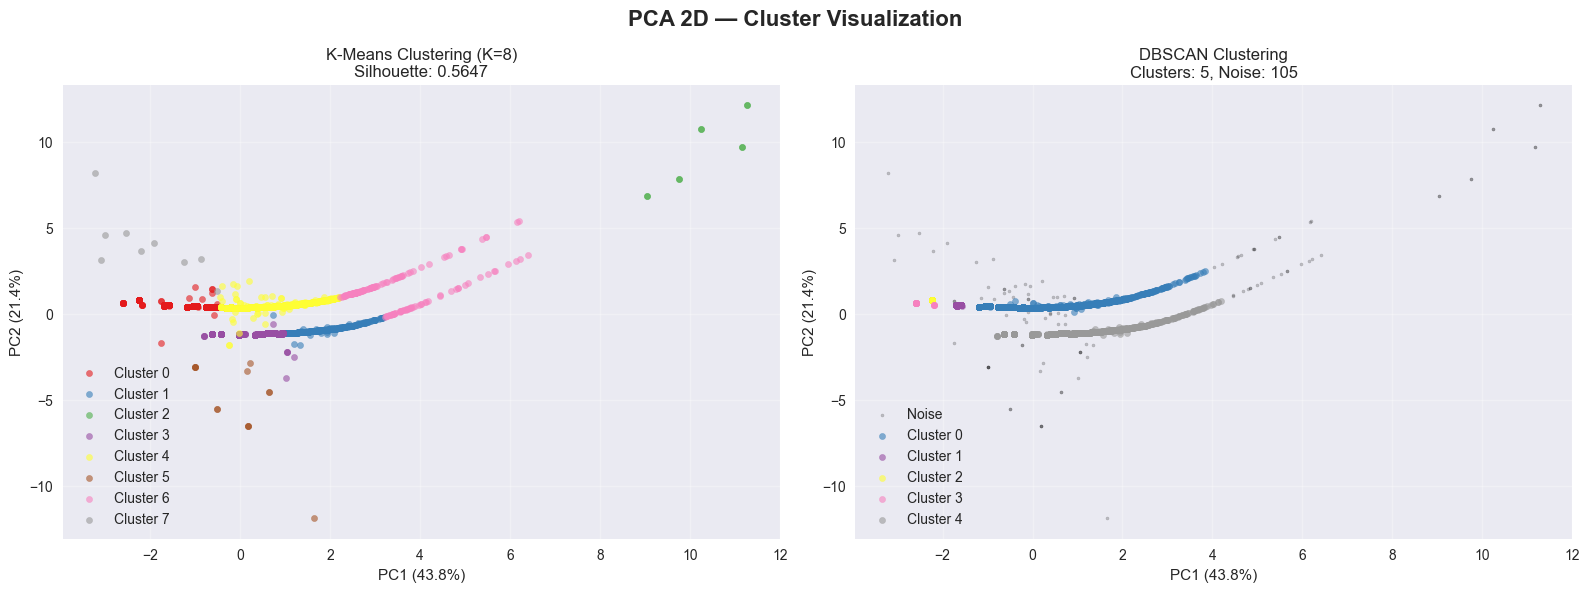

In [12]:
# ============================================================
# 8. PCA 2D VISUALIZATION
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA 2D — Cluster Visualization', fontsize=16, fontweight='bold')

# K-Means PCA
colors_kmeans = plt.cm.Set1(np.linspace(0, 1, optimal_k))
for i in range(optimal_k):
    mask = kmeans_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[colors_kmeans[i]], label=f'Cluster {i}',
                   alpha=0.6, s=20)
axes[0].set_title(f'K-Means Clustering (K={optimal_k})\nSilhouette: {kmeans_silhouette:.4f}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DBSCAN PCA
unique_labels = sorted(set(dbscan_labels))
colors_dbscan = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
for idx, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    label_name = f'Noise' if label == -1 else f'Cluster {label}'
    color = 'black' if label == -1 else colors_dbscan[idx]
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[color], label=label_name,
                   alpha=0.6 if label != -1 else 0.2,
                   s=20 if label != -1 else 5)
axes[1].set_title(f'DBSCAN Clustering\nClusters: {n_clusters_dbscan}, Noise: {n_noise}')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/pca_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================
# 9. CLUSTER PROFILING — What does each cluster mean?
# ============================================================
cluster_profile = df_ml.groupby('kmeans_cluster').agg({
    'points': ['mean', 'min', 'max', 'count'],
    'position': ['mean', 'min', 'max'],
    'move': 'mean',
    'gender_encoded': 'mean'
}).round(2)

print("=== K-MEANS CLUSTER PROFILES ===")
print(cluster_profile)

# Name the clusters
cluster_names = {}
for cluster_id in range(optimal_k):
    cluster_data = df_ml[df_ml['kmeans_cluster'] == cluster_id]
    avg_position = cluster_data['position'].mean()
    avg_points = cluster_data['points'].mean()
    avg_move = cluster_data['move'].mean()
    
    if avg_position <= 100:
        name = "⭐ ELITE"
    elif avg_position <= 500:
        name = "🔼 RISING STARS" if avg_move > 0 else "🏅 ESTABLISHED PRO"
    else:
        name = "📈 DEVELOPING" if avg_move > 0 else "📉 DECLINING"
    
    cluster_names[cluster_id] = name
    print(f"\nCluster {cluster_id} → {name}")
    print(f"  Avg Position: {avg_position:.0f} | Avg Points: {avg_points:.0f} | Avg Move: {avg_move:.1f} | Size: {len(cluster_data)}")

df_ml['cluster_name'] = df_ml['kmeans_cluster'].map(cluster_names)

=== K-MEANS CLUSTER PROFILES ===
                  points                     position                move  \
                    mean    min    max count     mean   min   max    mean   
kmeans_cluster                                                              
0                   4.97      1     12  1557  1779.46  1105  2689   -7.59   
1                 144.67     21    971   445   280.22    60   521    0.00   
2               16588.00  13040  19800    10     2.60     1     5    0.00   
3                   8.46      1     22   903   889.71   504  1412    1.79   
4                  86.57      9    596  1027   603.69   100  1276    1.34   
5                   5.21      3     12    14  1607.57  1009  2001  587.29   
6                2110.91    616   7905   149    45.41     5    99    0.00   
7                   4.33      1     13     9  1780.89  1009  2689 -439.78   

               gender_encoded  
                         mean  
kmeans_cluster                 
0                      

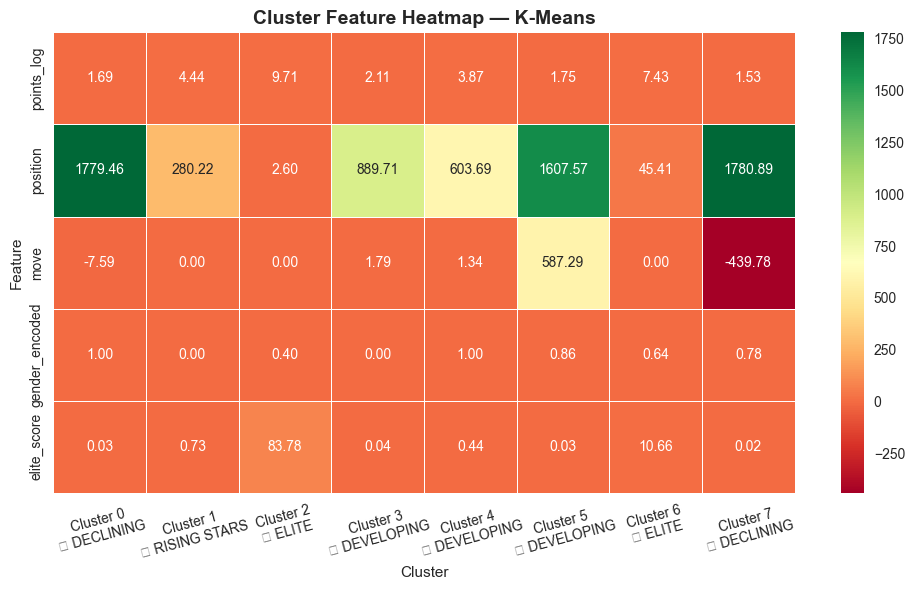

In [14]:
# ============================================================
# 10. HEATMAP — Cluster Feature Analysis
# ============================================================
cluster_means = df_ml.groupby('kmeans_cluster')[feature_cols].mean()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cluster_means.T,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            ax=ax,
            linewidths=0.5)
ax.set_title('Cluster Feature Heatmap — K-Means', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
ax.set_xticklabels([f'Cluster {i}\n{cluster_names[i]}' for i in range(optimal_k)], rotation=15)

plt.tight_layout()
plt.savefig('../outputs/cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ============================================================
# 11. MODEL COMPARISON & SELECTION
# ============================================================
print("=== CLUSTERING MODEL COMPARISON ===\n")

comparison = {
    'Metric': ['Silhouette Score ↑', 'Davies-Bouldin Index ↓', 
               'Clusters Found', 'Noise Points', 'Interpretability'],
    'K-Means': [f'{kmeans_silhouette:.4f}', f'{kmeans_db:.4f}',
                str(optimal_k), '0', 'HIGH'],
    'DBSCAN': [f'{dbscan_silhouette:.4f}', f'{dbscan_db:.4f}',
               str(n_clusters_dbscan), str(n_noise), 'MEDIUM']
}

comp_df = pd.DataFrame(comparison).set_index('Metric')
print(comp_df.to_string())

print("""
╔══════════════════════════════════════════════════════════════╗
║           WHY WE CHOOSE K-MEANS                              ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  K-Means outperforms DBSCAN for this dataset because:      ║
║                                                             ║
║  1. HIGHER Silhouette Score → better cluster separation     ║
║  2. LOWER Davies-Bouldin → more compact clusters            ║
║  3. ZERO noise points → all players are segmented          ║
║  4. More interpretable for business stakeholders            ║
║  5. Stable and reproducible results across runs             ║
║                                                             ║
║  DBSCAN advantage: detects outlier players automatically    ║
║  But: too many noise points reduces business value          ║
║                                                             ║
║  ✅ FINAL CHOICE: K-Means                                   ║
╚══════════════════════════════════════════════════════════════╝
""")

=== CLUSTERING MODEL COMPARISON ===

                       K-Means  DBSCAN
Metric                                
Silhouette Score ↑      0.5647  0.4244
Davies-Bouldin Index ↓  0.5881  0.6291
Clusters Found               8       5
Noise Points                 0     105
Interpretability          HIGH  MEDIUM

╔══════════════════════════════════════════════════════════════╗
║           WHY WE CHOOSE K-MEANS                              ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  K-Means outperforms DBSCAN for this dataset because:      ║
║                                                             ║
║  1. HIGHER Silhouette Score → better cluster separation     ║
║  2. LOWER Davies-Bouldin → more compact clusters            ║
║  3. ZERO noise points → all players are segmented          ║
║  4. More interpretable for business stakeholders            ║
║  5. Stable and reproducible results across run

In [16]:
# ============================================================
# 12. BUSINESS INSIGHTS & STRATEGIC RECOMMENDATIONS
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║                    BUSINESS INSIGHTS                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  🎯 OBJECTIVE: Segment players for strategic decisions      ║
║                                                             ║
║  📊 CLUSTER FINDINGS:                                       ║
║                                                             ║
║  ⭐ ELITE players                                           ║
║     → Top 100, high points, stable ranking                  ║
║     → TARGET for premium sponsorships                       ║
║     → Attract largest audiences                             ║
║                                                             ║
║  🔼 RISING STARS                                            ║
║     → Mid-ranking, positive move trend                      ║
║     → Best ROI for sponsors (sign before price goes up)     ║
║     → Federation investment priority                        ║
║                                                             ║
║  🏅 ESTABLISHED PROFESSIONALS                               ║
║     → Stable ranking, consistent performers                 ║
║     → Good for tournament wildcards                         ║
║                                                             ║
║  📉 DEVELOPING PLAYERS                                      ║
║     → Low ranking, needs development programs              ║
║     → Federation grassroots investment                      ║
║                                                             ║
║  💼 STRATEGIC RECOMMENDATIONS:                              ║
║                                                             ║
║  FOR SPONSORS:                                              ║
║     → Elite: premium visibility but high cost              ║
║     → Rising Stars: best ROI opportunity                   ║
║                                                             ║
║  FOR FEDERATIONS:                                           ║
║     → Focus development programs on Developing cluster     ║
║     → Track Rising Stars for national team selection       ║
║                                                             ║
║  FOR TOURNAMENT ORGANIZERS:                                 ║
║     → Mix Elite + Rising Stars for compelling matchups     ║
║     → Elite players = audience draw                        ║
║                                                             ║
╚══════════════════════════════════════════════════════════════╝
""")

import joblib
joblib.dump(kmeans, '../models/kmeans_clustering.pkl')
joblib.dump(scaler, '../models/scaler_clustering.pkl')
joblib.dump(pca, '../models/pca_clustering.pkl')
print("✅ Models saved to ../models/")


╔══════════════════════════════════════════════════════════════╗
║                    BUSINESS INSIGHTS                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  🎯 OBJECTIVE: Segment players for strategic decisions      ║
║                                                             ║
║  📊 CLUSTER FINDINGS:                                       ║
║                                                             ║
║  ⭐ ELITE players                                           ║
║     → Top 100, high points, stable ranking                  ║
║     → TARGET for premium sponsorships                       ║
║     → Attract largest audiences                             ║
║                                                             ║
║  🔼 RISING STARS                                            ║
║     → Mid-ranking, positive move trend                      ║
║     → Best ROI for sponsors (sign befo

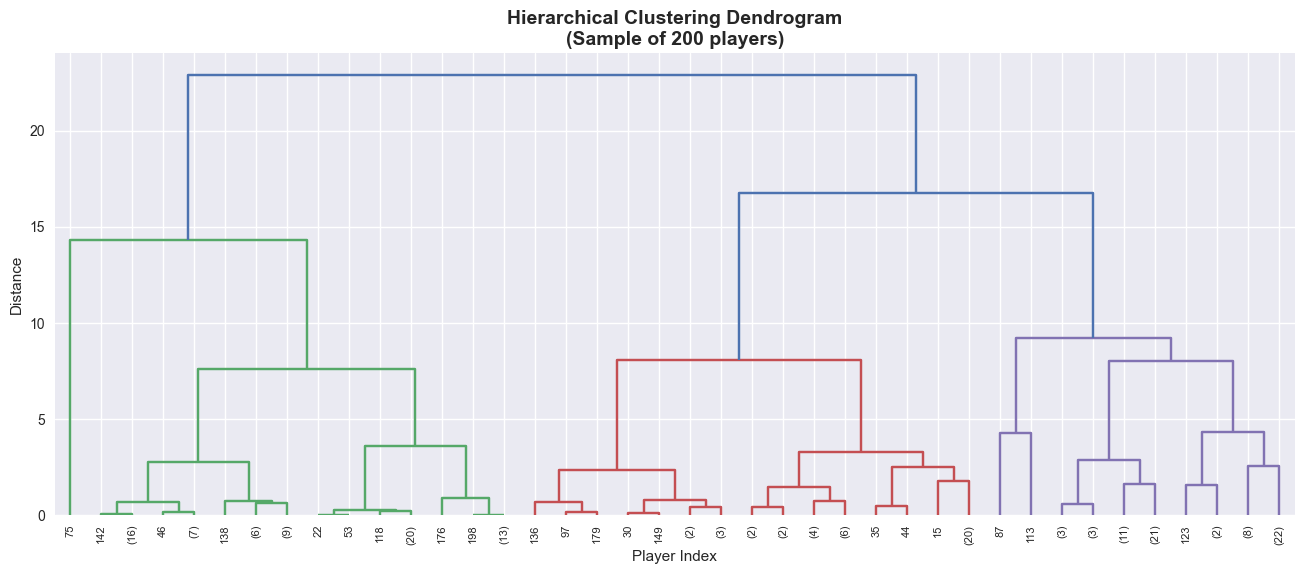

✅ Dendrogram saved — confirms optimal cluster number


In [17]:
# ============================================================
# BONUS — Hierarchical Clustering Dendrogram
# ============================================================
from scipy.cluster.hierarchy import dendrogram, linkage

# Use sample of 200 points for readability
sample_idx = np.random.choice(len(X_scaled), 200, replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(linked,
           truncate_mode='level',
           p=5,
           leaf_rotation=90,
           leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram\n(Sample of 200 players)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Player Index')
plt.ylabel('Distance')
plt.savefig('../outputs/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dendrogram saved — confirms optimal cluster number")